**Introduction to Sequential Data**

What is Sequential Data?

Sequential data is information where the order of elements matters.

| Sequence     | Why Order Matters                          |
| ------------ | ------------------------------------------ |
| Sentence     | "I love AI" ≠ "AI love I"                  |
| Stock Prices | Today's price depends on yesterday's price |
| Weather      | Tomorrow depends on previous days          |
| Speech       | Sound occurs over time                     |
| DNA Sequence | Order determines biological meaning        |


Changing the order changes the meaning.

Why Feedforward Neural Networks (FNN) Fail?

A normal neural network treats every input independently.

Example:

Suppose we want to predict the next word.

Sentence:

The cat sat on the ______

A Feedforward Neural Network only looks at

Input = "the"

It ignores
* The
* cat
* sat
* on

Therefore it cannot predict mat correctly.

Problem:
1. No memory
2. Cannot remember previous inputs
3. Cannot process sequences

**What is a Recurrent Neural Network (RNN)?**

RNN (Recurrent Neural Network) is a type of artificial neural network designed to process sequential data, where the order of the data matters. Unlike a standard neural network, an RNN has a memory that allows it to use information from previous inputs when processing the current input.

How it works?
Imagine you're reading a sentence word by word:

"The cat sat on the ___."

At each time step:

It receives the current input.
It combines it with the previous hidden state (its memory).
It produces:
a new hidden state (updated memory), and
optionally, an output.

A simplified equation is:
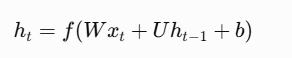

where:

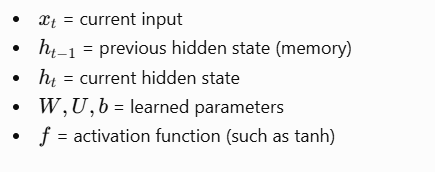

**Applications**

RNNs are commonly used for:

1. Natural Language Processing (text generation, translation, sentiment analysis)
2. Speech recognition
3. Time-series forecasting (stock prices, weather)
4. Handwriting recognition
5. Music generation

**Advantages of RNN:**

✔ Works well with sequential data

✔ Has memory

✔ Suitable for text

✔ Suitable for speech

✔ Variable input length

**Disadvantages of RNN:**

Major problem:

1. Vanishing Gradient Problem

During training, errors travel backward.

2. Exploding Gradient(Opposite case)

Gradient becomes extremely large. Training becomes unstable.

**Why Does RNN Forget?**

Example: Sentence

The weather in Hyderabad today is sunny,
although yesterday it was raining heavily...

To predict

* today

RNN must remember information from many words earlier.

Standard RNN struggles to retain such long-term information.

Solution → LSTM
:
LSTM

=

Long Short-Term Memory Network

Introduced in 1997 by Sepp Hochreiter and Jürgen Schmidhuber.

Purpose

Remember important information

Forget unnecessary information

**LSTM (Long Short-Term Memory)** is a special type of Recurrent Neural Network (RNN) designed to learn from sequential data such as text, speech, time-series data, and stock prices. It solves the problem of remembering important information for a long time.

**Why Do We Need LSTM?**

Imagine reading this sentence:

"John went to the store. He bought some apples."

When you read "He", you know it refers to John because you remember the earlier word.

Computers also need memory when processing sequences.

Examples:

1. Predicting the next word in a sentence
2. Translating languages
3. Speech recognition
4. Weather prediction
5. Stock price prediction

Normal neural networks process each input independently and cannot remember previous information.

LSTM is like a smart memory box.

Instead of remembering everything, it decides:

* What to remember
* What to forget
* What to output

Think of it like your brain.

Example:

You remember your birthday but forget what you ate three months ago.

LSTM learns what information is important.

  LSTM Architecture:
          
There are three gates:

1. Forget Gate
2. Input Gate
3. Output Gate
-------------------------------------------------------------------------------
1. Forget Gate

The first step is deciding what information to remove.

Example: Sentence:

"I grew up in Hyderabad. Now I live in Bangalore."

When predicting the current city, the model may forget the old city because it is no longer relevant.

Formula:

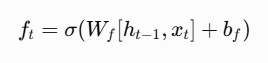

Where:

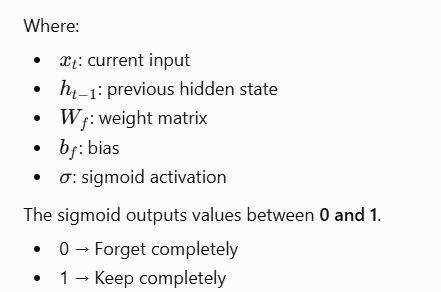

2. Input Gate

Now LSTM decides what new information to store.

Example: Current word = Bangalore

The model decides to store this city.

Formula:  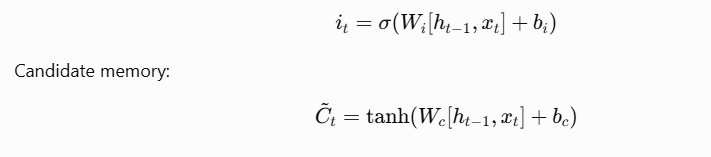





3. Updating the Cell State

Old memory:

I live in Hyderabad

New information:

I now live in Bangalore

Updated memory:

I live in Bangalore

Formula:

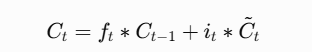

This means:

New Memory =
Old Memory kept
+
New Important Information

4. Output Gate

Finally, the LSTM decides what information to output.

Formula:

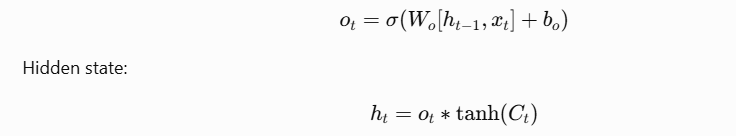

This hidden state is passed to:

the next LSTM cell
the output layer

**Applications of LSTM**

LSTMs are widely used for sequence-based tasks such as:

1. Text prediction (e.g., predicting the next word)
2. Machine translation
3. Speech recognition
4. Handwriting recognition
5. Time-series forecasting (weather, stock prices, sales)
6. Sentiment analysis
7. Music generation
8. Video analysis

**RNN vs LSTM**

| Feature                | RNN               | LSTM                        |
| ---------------------- | ----------------- | --------------------------- |
| Memory                 | Short-term        | Long-term                   |
| Vanishing Gradient     | Significant issue | Greatly reduced             |
| Handles Long Sequences | Poorly            | Well                        |
| Uses Gates             | No                | Yes (Forget, Input, Output) |
| Complexity             | Simple            | More complex                |


Simple Analogy

Imagine you are preparing for an exam.

* Forget Gate: Discard topics that won't be on the exam.
* Input Gate: Learn and store new important topics.
* Cell State: Your long-term memory notebook.
* Output Gate: Use the relevant knowledge to answer the current question.

In [ ]:
# Import TensorFlow library
import tensorflow as tf

# Import IMDb dataset (movie reviews)
from tensorflow.keras.datasets import imdb

# Used to make all reviews the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sequential model allows stacking layers one after another
from tensorflow.keras.models import Sequential

# Import required layers
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


# -----------------------------------------
# STEP 1: Define Parameters
# -----------------------------------------

# Number of unique words to keep in vocabulary
# Only the top 10,000 most frequent words are used
vocab_size = 10000

# Every review will have exactly 200 words
# Short reviews are padded with zeros
# Long reviews are truncated
max_length = 200


# -----------------------------------------
# STEP 2: Load IMDb Dataset
# -----------------------------------------

# X_train -> Reviews (already converted into integers)
# y_train -> Labels (0 = Negative, 1 = Positive)

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)


# Example review
print(X_train[0])

# Example label
print(y_train[0])


# -----------------------------------------
# STEP 3: Pad Sequences
# -----------------------------------------

# Reviews have different lengths.
# Convert every review to length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)


# Check shape
print(X_train.shape)

# Output:
# (25000, 200)
#
# 25000 reviews
# Each review contains 200 integers

# -----------------------------------------
# STEP 4: Build the Model
# -----------------------------------------

model = Sequential()


# -----------------------------------------
# Embedding Layer
# -----------------------------------------

# Input:
# (batch_size, 200)

# Output:
# (batch_size, 200, 64)

# Every integer becomes a vector of length 64

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)


# -----------------------------------------
# Simple RNN Layer
# -----------------------------------------

# Reads one word at a time.

# Maintains a hidden state (memory).

# Returns only the last hidden state.

model.add(
    SimpleRNN(
        units=64
    )
)


# -----------------------------------------
# Output Layer
# -----------------------------------------

# One neuron

# Sigmoid outputs probability between 0 and 1

model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)


# Display model architecture
model.summary()


# -----------------------------------------
# STEP 5: Compile Model
# -----------------------------------------

model.compile(

    # Optimizer updates weights
    optimizer="adam",

    # Binary classification
    loss="binary_crossentropy",

    # Evaluation metric
    metrics=["accuracy"]
)


# -----------------------------------------
# STEP 6: Train Model
# -----------------------------------------

history = model.fit(

    X_train,

    y_train,

    epochs=50,

    batch_size=64,

    validation_split=0.2

)
# -----------------------------------------
# STEP 7: Evaluate Model
# -----------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy =", accuracy)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1
(25000,

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.6302 - loss: 0.6318 - val_accuracy: 0.7048 - val_loss: 0.5744
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.8087 - loss: 0.4282 - val_accuracy: 0.8252 - val_loss: 0.4122
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.8675 - loss: 0.3210 - val_accuracy: 0.8274 - val_loss: 0.3995
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.8850 - loss: 0.2838 - val_accuracy: 0.8244 - val_loss: 0.4271
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.9094 - loss: 0.2322 - val_accuracy: 0.8320 - val_loss: 0.4360
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.9157 - loss: 0.2176 - val_accuracy: 0.7208 - val_loss: 0.5732
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.9275 - loss: 0.1909 - val_accuracy: 0.8226 - val_loss: 0.4919
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.9476 - loss: 0.1469 - 

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Training sentences
train_sentences = [
    "I love this movie",
    "This movie is amazing",
    "I hate this movie",
    "This movie is terrible"
]

# Create tokenizer
tokenizer = Tokenizer()

# Learn the vocabulary
tokenizer.fit_on_texts(train_sentences)

# Your input
sentence = ["I hate this movie"]

# Convert to sequence
sequence = tokenizer.texts_to_sequences(sentence)

print(sequence)

sequence = pad_sequences(sequence, maxlen=200)

# Predict
prediction = model.predict(sequence)

print(prediction)

if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")


[[3, 7, 1, 2]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
[[0.55959344]]
Positive
